<a href="https://colab.research.google.com/github/njones61/xslope/blob/main/docs/lim_eq/xslope_lem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XSLOPE - Limit Equilibrium Method

This notebook illustrates how to use xslope to solve basic slope stability problems using the limit equilibrium method.

## Install xslope and import functions

In [2]:
# Install the xslope package
# - Basic install (limit equilibrium only): pip install xslope
# - Full install (with FEM features): pip install xslope[fem]

!pip install -i https://test.pypi.org/simple/ xslope==0.1.2

Looking in indexes: https://test.pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 3.7 MB/s eta 0:00:00


In [3]:
# Import functions

import xslope as xslope

from xslope.global_config import non_circ
from xslope.slice import generate_slices
from xslope.fileio import load_slope_data, load_data_from_pickle
from xslope.plot import plot_circular_search_results, plot_inputs, plot_solution
from xslope.solve import oms, bishop, janbu, corps_engineers, lowe_karafiath, spencer
from xslope.search import circular_search, noncircular_search

## Upload Excel Template

In [11]:
# Upload excel input template for selected problem

from google.colab import files
upload = files.upload()
file_name = list(upload.keys())[0]

Saving input_template_rface6.xlsx to input_template_rface6.xlsx


## Define Local Functions

In [21]:
def solve_selected(method_name, slice_df, rapid=False):

    func = getattr(xslope.solve, method_name)

    if rapid:
        success, result = rapid_drawdown(slice_df, func)
    else:
        success, result = func(slice_df)
    if not success:
        print(f'Error: {result}')
        return result

    if func == oms:
        print(f'OMS: FS={result["FS"]:.3f}')
    elif func == bishop:
        print(f'Bishop: FS={result["FS"]:.3f}')
    elif func == spencer:
        print(f'Spencer: FS={result["FS"]:.3f}, theta={result["theta"]:.2f}')
    elif func == janbu:
        print(f'Janbu Corrected FS={result["FS"]:.3f}, fo={result["fo"]:.2f}')
    elif func == corps_engineers:
        print(f'Corps Engineers: FS={result["FS"]:.3f}, theta={result["theta"]:.2f}')
    elif func == lowe_karafiath:
        print(f'Lowe & Karafiath: FS={result["FS"]:.3f}')
    return result

def solve_all(slice_df):
    solve_selected(oms, slice_df)
    solve_selected(bishop, slice_df)
    solve_selected(janbu, slice_df)
    solve_selected(corps_engineers, slice_df)
    solve_selected(lowe_karafiath, slice_df)
    solve_selected(spencer, slice_df)

## Load slope data

In [18]:
slope_data = load_slope_data(file_name)

circle = slope_data['circles'][0] if slope_data['circular'] else None
non_circ = slope_data['non_circ'] if slope_data['non_circ'] else None

success, result = generate_slices(slope_data, circle=circle, non_circ=None, num_slices=50)

if success:
    slice_df, failure_surface = result
else:
    print(result)
    exit()

## Plot inputs

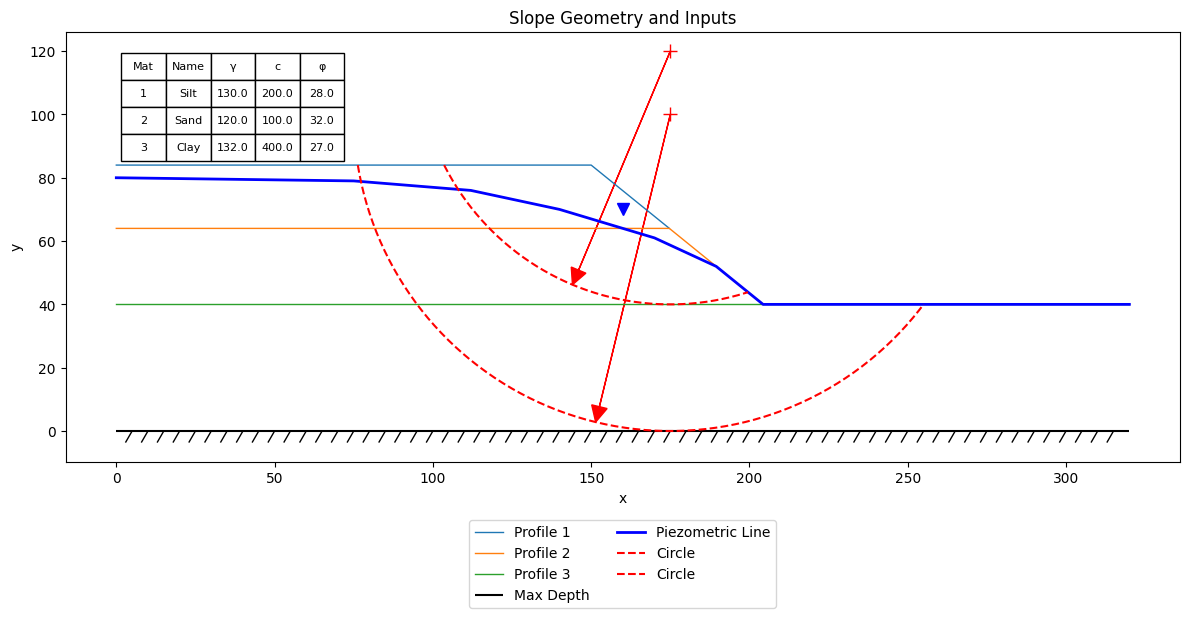

In [19]:
plot_inputs(slope_data)

In [28]:
# @title Select Options {"run":"auto"}
method = "corps_engineers" # @param ["oms","bishop","janbu","corps_engineers","lowe_karafiath","spencer"]



## Solve selected failure surface

Corps Engineers: FS=2.245, theta=13.83


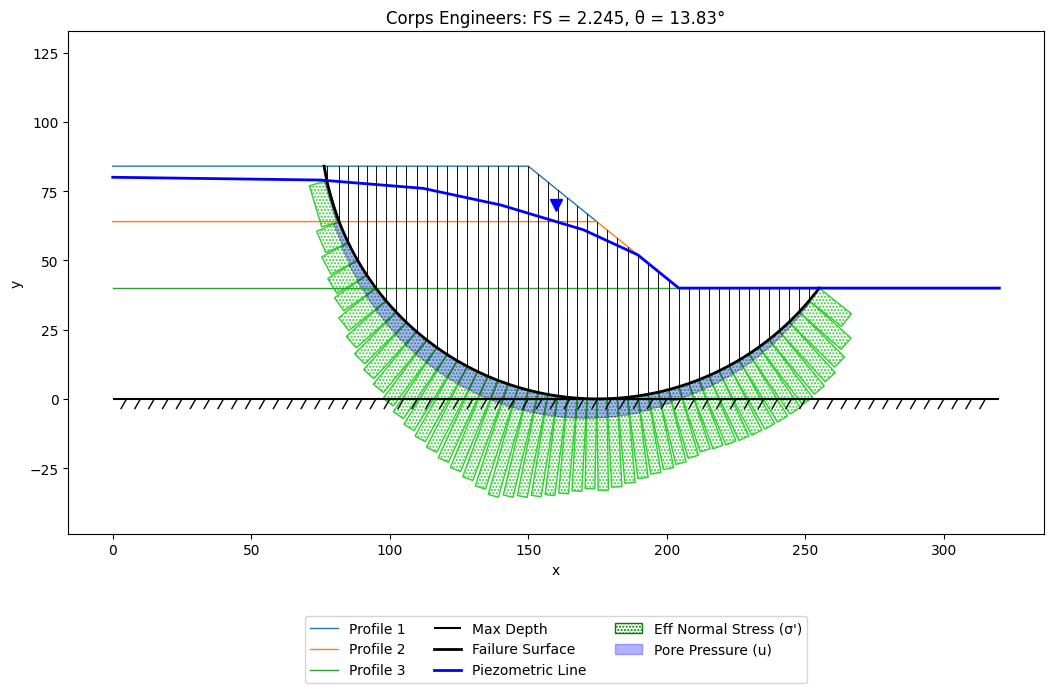

In [29]:
results = solve_selected(method, slice_df, rapid=False)
plot_solution(slope_data, slice_df, failure_surface, results)

## Automated search for critical surface

[🔁 iteration 1] center=(187.00, 108.00), FS=1.0521, grid=10.2000
[🔁 iteration 2] center=(197.20, 97.80), FS=0.8480, grid=10.2000
[🔁 iteration 3] center=(207.40, 87.60), FS=0.7772, grid=10.2000


/usr/local/lib/python3.12/dist-packages/xslope/solve.py:721: RuntimeWarning: divide by zero encountered in divide
  dyQ_dF = (-1 / (Q * cos_theta)**2) * Mo * dQ_dF * cos_theta
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:722: RuntimeWarning: divide by zero encountered in divide
  dyQ_dtheta = (-1 / (Q * cos_theta)**2) * Mo * (dQ_dtheta * cos_theta - Q * sin_theta)


[🔁 iteration 4] center=(207.40, 77.40), FS=0.7753, grid=10.2000


/usr/local/lib/python3.12/dist-packages/xslope/solve.py:721: RuntimeWarning: divide by zero encountered in divide
  dyQ_dF = (-1 / (Q * cos_theta)**2) * Mo * dQ_dF * cos_theta
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:722: RuntimeWarning: divide by zero encountered in divide
  dyQ_dtheta = (-1 / (Q * cos_theta)**2) * Mo * (dQ_dtheta * cos_theta - Q * sin_theta)


[🔁 iteration 5] center=(207.40, 77.40), FS=0.7753, grid=5.1000


...

[🔁 iteration 6] center=(202.30, 72.30), FS=0.7709, grid=5.1000


/usr/local/lib/python3.12/dist-packages/xslope/solve.py:721: RuntimeWarning: divide by zero encountered in divide
  dyQ_dF = (-1 / (Q * cos_theta)**2) * Mo * dQ_dF * cos_theta
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:722: RuntimeWarning: divide by zero encountered in divide
  dyQ_dtheta = (-1 / (Q * cos_theta)**2) * Mo * (dQ_dtheta * cos_theta - Q * sin_theta)


[🔁 iteration 7] center=(202.30, 72.30), FS=0.7709, grid=2.5500
[🔁 iteration 8] center=(204.85, 72.30), FS=0.7624, grid=2.5500


/usr/local/lib/python3.12/dist-packages/xslope/solve.py:721: RuntimeWarning: divide by zero encountered in divide
  dyQ_dF = (-1 / (Q * cos_theta)**2) * Mo * dQ_dF * cos_theta
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:722: RuntimeWarning: divide by zero encountered in divide
  dyQ_dtheta = (-1 / (Q * cos_theta)**2) * Mo * (dQ_dtheta * cos_theta - Q * sin_theta)
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:721: RuntimeWarning: divide by zero encountered in divide
  dyQ_dF = (-1 / (Q * cos_theta)**2) * Mo * dQ_dF * cos_theta
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:722: RuntimeWarning: divide by zero encountered in divide
  dyQ_dtheta = (-1 / (Q * cos_theta)**2) * Mo * (dQ_dtheta * cos_theta - Q * sin_theta)
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:721: RuntimeWarning: divide by zero encountered in divide
  dyQ_dF = (-1 / (Q * cos_theta)**2) * Mo * dQ_dF * cos_theta
/usr/local/lib/python3.12/dist-packages/xslope/solve.py:722: Runtime

[✅ converged] Iter=8, FS=0.7624 at (x=204.85, y=72.30, depth=40.00), elapsed time=10.63 seconds


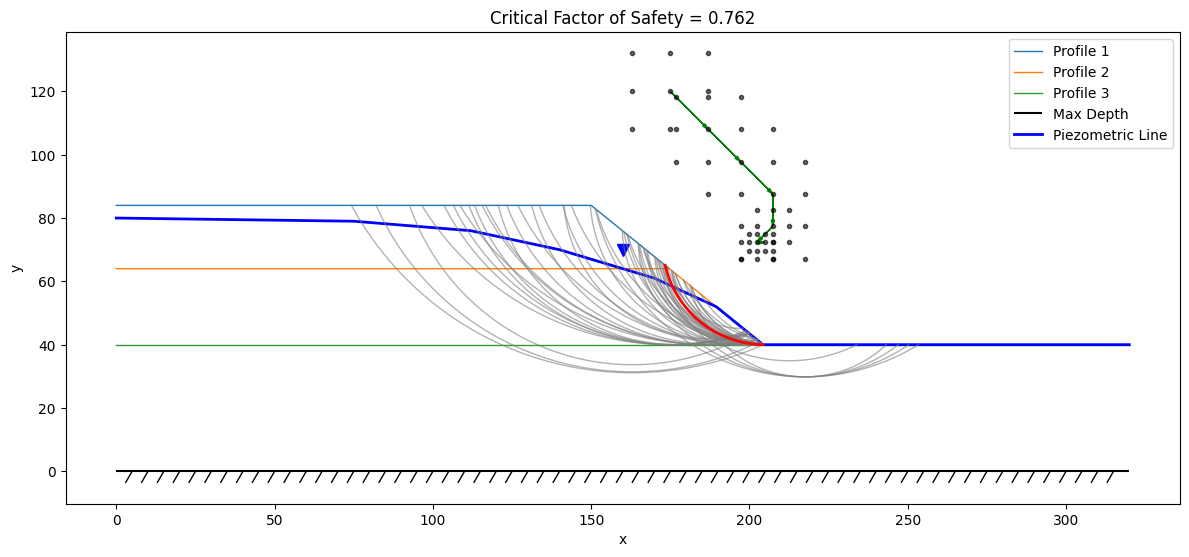

In [16]:
fs_cache, converged, search_path = circular_search(slope_data, spencer, diagnostic=False)


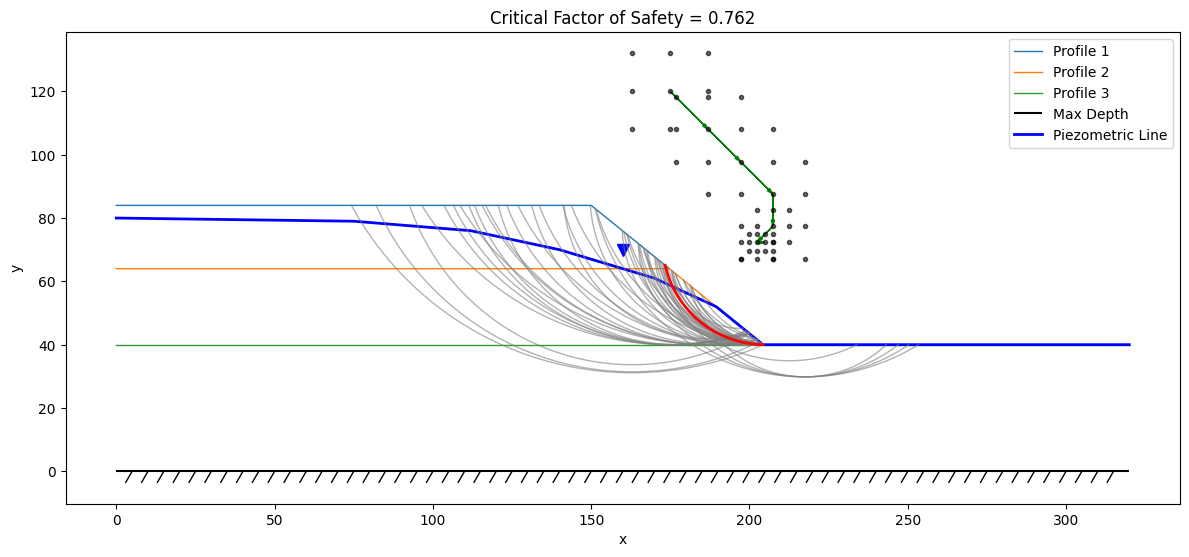

In [17]:
plot_circular_search_results(slope_data, fs_cache, search_path)